# Loan Applicant Credit Risk and Approval Readiness Score

This notebook cleans, analyzes, and scores 981 loan applications to build an Approval Readiness Score, a scorecard that estimates how ready each applicant looks for approval.

## Part 1: The Raw Data

Before touching anything, let's look at the data exactly as it arrived.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120

df_raw = pd.read_csv('raw_data.csv')
print("Shape (rows, columns):", df_raw.shape)
df_raw.head(10)

Shape (rows, columns): (981, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,m,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Uban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban
3,LP001035,m,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422.0,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0.0,59.0,360.0,1.0,Semiurban
7,LP001056,m,Yes,2,Not Graduate,No,3881,0.0,147.0,360.0,0.0,Rurl
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0.0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400.0,123.0,360.0,1.0,Semiurban


## Part 2: Data Quality Check, Before Cleaning

Before analyzing anything, we need to know what's actually reliable in this file and what isn't.

In [60]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    object 
 1   Gender             957 non-null    object 
 2   Married            978 non-null    object 
 3   Dependents         956 non-null    object 
 4   Education          981 non-null    object 
 5   Self_Employed      926 non-null    object 
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 92.1+ KB


Columns with missing values:
Credit_History      79
Self_Employed       55
LoanAmount          27
Dependents          25
Gender              24
Loan_Amount_Term    20
Married              3
dtype: int64


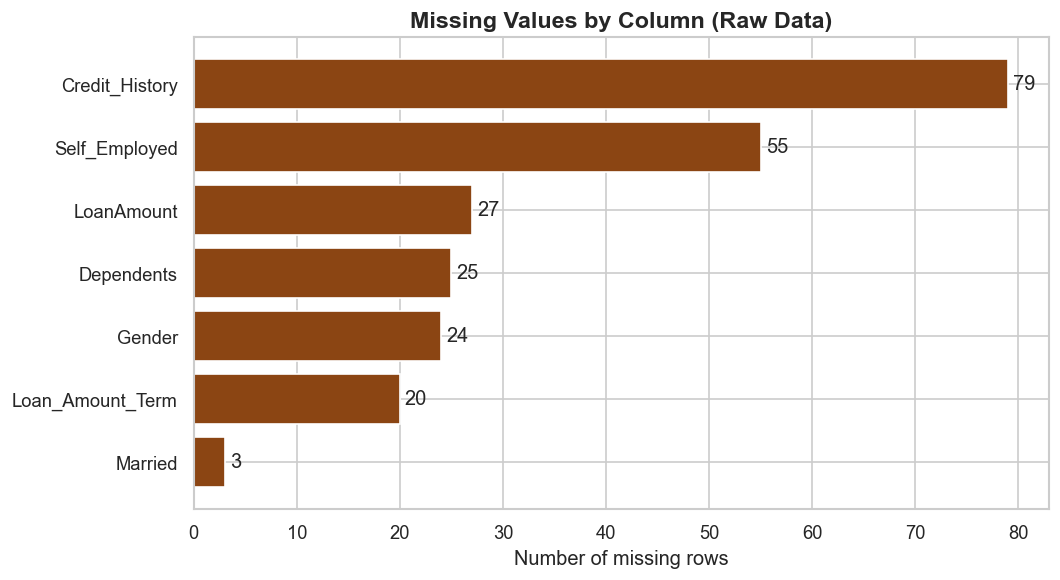

In [61]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(missing.index, missing.values, color="#8B4513")
ax.set_title("Missing Values by Column (Raw Data)", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of missing rows")
ax.bar_label(bars, padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [62]:
print("Unique Gender values:", df_raw['Gender'].unique())
print("\nUnique Property_Area values:", df_raw['Property_Area'].unique())
print("\nUnique Dependents values:", df_raw['Dependents'].unique())

Unique Gender values: ['m' 'Male' 'Female' 'f' nan]

Unique Property_Area values: ['Urban' 'Uban' 'Semiurban' 'Rurl' 'Semiurbn' 'Rural' 'Urben' 'Urbun'
 'Semiurben' 'Semurban' 'Rurel' 'Rurall' 'Rual' 'Urbn']

Unique Dependents values: ['0' '1' '2' '3+' nan]


In [63]:
dupes = df_raw.duplicated(subset=['Loan_ID']).sum()
negative_income = (df_raw['ApplicantIncome'] < 0).sum()
zero_or_less_loan = (df_raw['LoanAmount'] <= 0).sum()

print("Duplicate Loan_IDs:", dupes)
print("Negative income rows:", negative_income)
print("Zero or negative loan amounts:", zero_or_less_loan)

Duplicate Loan_IDs: 0
Negative income rows: 0
Zero or negative loan amounts: 0


### What We Found

**What was fine:**
- No duplicate applications (Loan_ID is unique for every row)
- No negative incomes or impossible loan amounts
- Numeric columns (ApplicantIncome, CoapplicantIncome) had no missing values

**What was wrong:**
- Gender had two spellings for the same value ("Male" and "m", "Female" and "f")
- Property_Area had 14 different misspellings of only 3 real places (e.g. "Uban", "Rurl", "Semiurbn")
- Dependents mixed real numbers (0, 1, 2) with text ("3+")
- Seven columns had missing values: Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History
- LoanAmount was stored in thousands with no label saying so

## Part 3: Cleaning the Data

### Step 1: Fix Data Types First

Before fixing anything else, we check that every column is stored as the correct type. A number stored as text can break averages, comparisons, and calculations later, so this needs to happen before any other cleaning step.

In [64]:
df = df_raw.copy()

print("Data types before fixing:")
print(df.dtypes)

Data types before fixing:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object


Two problems show up here. First, ApplicantIncome, CoapplicantIncome, LoanAmount, and Loan_Amount_Term should all be numbers we can do math on. Second, Dependents mixes real numbers (0, 1, 2) with a text value ("3+"), which blocks normal math on that column entirely.

In [65]:
# Make sure income and loan columns are true numbers
for c in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']:
    df[c] = df[c].astype(float)

# Dependents mixes numbers with text ("3+"), fix by keeping a text version
# and creating a separate, fully numeric version
df['Dependents'] = df['Dependents'].astype('string')
df['Dependents_numeric'] = df['Dependents'].replace({'3+': '3'}).astype('Float64')

print("Data types after fixing:")
print(df[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']].dtypes)
print("\nDependents (text) and Dependents_numeric (number) side by side:")
print(df[['Dependents', 'Dependents_numeric']].drop_duplicates().sort_values('Dependents_numeric'))

Data types after fixing:
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
dtype: object

Dependents (text) and Dependents_numeric (number) side by side:
   Dependents  Dependents_numeric
0           0                 0.0
1           1                 1.0
2           2                 2.0
12         3+                 3.0
46       <NA>                <NA>


### Step 2: Remove Stray Spaces and Fix Inconsistent Labels

With data types fixed, we can now safely clean up the text values. First we strip extra spaces, then we fix values like Gender and Property_Area that represent the same thing but are written differently.

In [66]:
str_cols = df.select_dtypes(include='object').columns.tolist() + ['Loan_ID']
str_cols = list(dict.fromkeys(str_cols))
for c in str_cols:
    df[c] = df[c].astype('string').str.strip()

df['Gender'] = df['Gender'].replace({'m': 'Male', 'f': 'Female'})

area_map = {
    'Urban': 'Urban', 'Uban': 'Urban', 'Urben': 'Urban', 'Urbun': 'Urban', 'Urbn': 'Urban',
    'Semiurban': 'Semiurban', 'Semiurbn': 'Semiurban', 'Semiurben': 'Semiurban', 'Semurban': 'Semiurban',
    'Rural': 'Rural', 'Rurl': 'Rural', 'Rurel': 'Rural', 'Rurall': 'Rural', 'Rual': 'Rural'
}
df['Property_Area'] = df['Property_Area'].map(area_map)

print("Gender now has", df['Gender'].nunique(), "categories:", df['Gender'].dropna().unique().tolist())
print("Property_Area collapsed from 14 messy values down to", df['Property_Area'].nunique(), "clean categories:", df['Property_Area'].unique().tolist())

Gender now has 2 categories: ['Male', 'Female']
Property_Area collapsed from 14 messy values down to 3 clean categories: ['Urban', 'Semiurban', 'Rural']


### Step 3: Fill In Missing Values

For categories (Gender, Married, Self_Employed, Dependents), we fill gaps with the mode, the most common answer. For numbers (LoanAmount, Loan_Amount_Term), we use the median, the middle value, which isn't thrown off by a few unusually large or small numbers.

In [67]:
for c in ['Gender', 'Married', 'Self_Employed', 'Dependents']:
    filled_count = df[c].isnull().sum()
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
    print(f"{c}: filled {filled_count} missing values with '{df[c].mode()[0]}'")

for c in ['LoanAmount', 'Loan_Amount_Term']:
    filled_count = df[c].isnull().sum()
    df[c] = df[c].fillna(df[c].median())
    print(f"{c}: filled {filled_count} missing values with {df[c].median()}")

Gender: filled 24 missing values with 'Male'
Married: filled 3 missing values with 'Yes'
Self_Employed: filled 55 missing values with 'No'
Dependents: filled 25 missing values with '0'
LoanAmount: filled 27 missing values with 126.0
Loan_Amount_Term: filled 20 missing values with 360.0


### Step 4: Handle Credit_History Carefully, This One Is Different

Unlike the columns above, we do not guess a value for missing Credit_History. It could be meaningful on its own, someone with no credit history on file at all. Guessing "yes" or "no" would hide that, so we keep it as its own honest category.

In [68]:
missing_credit = df['Credit_History'].isnull().sum()

df['Credit_History_Status'] = df['Credit_History'].map({1.0: 'Has Credit History', 0.0: 'No Credit History'})
df['Credit_History_Status'] = df['Credit_History_Status'].fillna('Unknown/Not on File')

print(f"{missing_credit} applicants had no credit history on file.")
print(df['Credit_History_Status'].value_counts())

79 applicants had no credit history on file.
Credit_History_Status
Has Credit History     754
No Credit History      148
Unknown/Not on File     79
Name: count, dtype: int64


### Step 5: Remove Duplicates and Add Columns Needed for Analysis

In [69]:
before_rows = len(df)
df = df.drop_duplicates(subset=['Loan_ID'])
print(f"Duplicate rows removed: {before_rows - len(df)}")

df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LoanAmount_Actual'] = df['LoanAmount'] * 1000
df['Loan_to_Income_Ratio'] = df['LoanAmount_Actual'] / df['TotalIncome'].replace(0, np.nan)
df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] / 1000 + 1)
df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)

print("\nCleaning complete.")
print("Before:", df_raw.shape, "  After:", df.shape)

Duplicate rows removed: 0

Cleaning complete.
Before: (981, 12)   After: (981, 19)


## Part 4: The Cleaned Dataset

Let's confirm the cleaning actually worked before moving to analysis.

In [70]:
print("Missing values remaining:")
print(df[['Gender','Married','Dependents','Self_Employed','LoanAmount','Loan_Amount_Term']].isnull().sum())
print("\nGender values now:", df['Gender'].unique())
print("Property_Area values now:", df['Property_Area'].unique())

df.to_csv('cleaned_data_from_notebook.csv', index=False)
df.head(10)

Missing values remaining:
Gender              0
Married             0
Dependents          0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
dtype: int64

Gender values now: <StringArray>
['Male', 'Female']
Length: 2, dtype: string
Property_Area values now: ['Urban' 'Semiurban' 'Rural']


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Dependents_numeric,Credit_History_Status,TotalIncome,LoanAmount_Actual,Loan_to_Income_Ratio,LoanIncomeRatio,Has_Coapplicant
0,LP001015,Male,Yes,0,Graduate,No,5720.0,0.0,110.0,360.0,1.0,Urban,0.0,Has Credit History,5720.0,110000.0,19.230769,16.369048,0
1,LP001022,Male,Yes,1,Graduate,No,3076.0,1500.0,126.0,360.0,1.0,Urban,1.0,Has Credit History,4576.0,126000.0,27.534965,22.596844,1
2,LP001031,Male,Yes,2,Graduate,No,5000.0,1800.0,208.0,360.0,1.0,Urban,2.0,Has Credit History,6800.0,208000.0,30.588235,26.666667,1
3,LP001035,Male,Yes,2,Graduate,No,2340.0,2546.0,100.0,360.0,NaN,Urban,2.0,Unknown/Not on File,4886.0,100000.0,20.466639,16.989467,1
4,LP001051,Male,No,0,Not Graduate,No,3276.0,0.0,78.0,360.0,1.0,Urban,0.0,Has Credit History,3276.0,78000.0,23.809524,18.241347,0
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165.0,3422.0,152.0,360.0,1.0,Urban,0.0,Has Credit History,5587.0,152000.0,27.206014,23.075755,1
6,LP001055,Female,No,1,Not Graduate,No,2226.0,0.0,59.0,360.0,1.0,Semiurban,1.0,Has Credit History,2226.0,59000.0,26.504942,18.288903,0
7,LP001056,Male,Yes,2,Not Graduate,No,3881.0,0.0,147.0,360.0,0.0,Rural,2.0,No Credit History,3881.0,147000.0,37.876836,30.116779,0
8,LP001059,Male,Yes,2,Graduate,No,13633.0,0.0,280.0,240.0,1.0,Urban,2.0,Has Credit History,13633.0,280000.0,20.538399,19.134832,0
9,LP001067,Male,No,0,Not Graduate,No,2400.0,2400.0,123.0,360.0,1.0,Semiurban,0.0,Has Credit History,4800.0,123000.0,25.625000,21.206897,1


## Part 5: Analysis and Charts

Now that the data is clean, let's answer six questions about what drives credit history, and look at how income and loan size relate to each other.

In [71]:
def pretty_bar(data, title, ylabel, color="#4B2E5B", figsize=(8, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(data.index.astype(str), data.values, color=color, edgecolor="white", linewidth=1.2)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.bar_label(bars, fmt="%.1f", padding=4, fontsize=10, fontweight="bold")
    ax.spines[['top', 'right']].set_visible(False)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

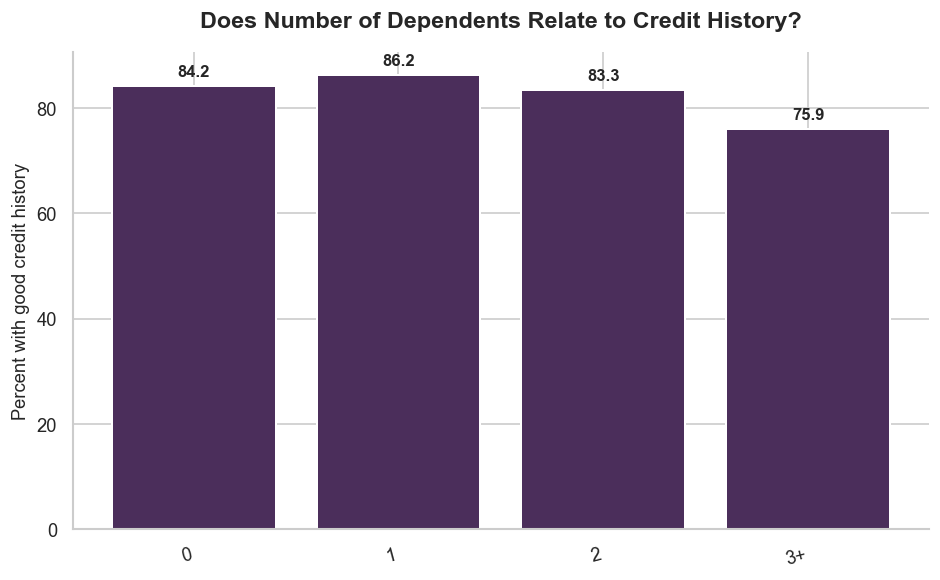

In [72]:
rate_dep = (df.groupby("Dependents")["Credit_History"].mean() * 100).round(1)
pretty_bar(rate_dep, "Does Number of Dependents Relate to Credit History?", "Percent with good credit history")

**What this shows:** Applicants with 3 or more dependents have the lowest credit history rate (75.9%), noticeably below smaller households (83–86%). This is the biggest gap of any group we checked.

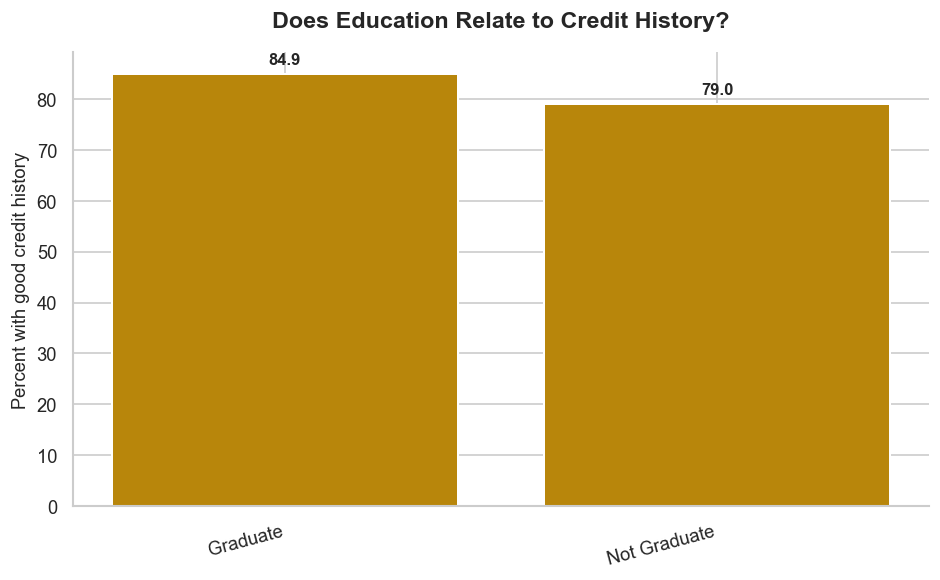

In [73]:
rate_edu = (df.groupby("Education")["Credit_History"].mean() * 100).round(1)
pretty_bar(rate_edu, "Does Education Relate to Credit History?", "Percent with good credit history", color="#B8860B")

**What this shows:** Graduates have a somewhat higher credit history rate than non-graduates, a modest but real gap.

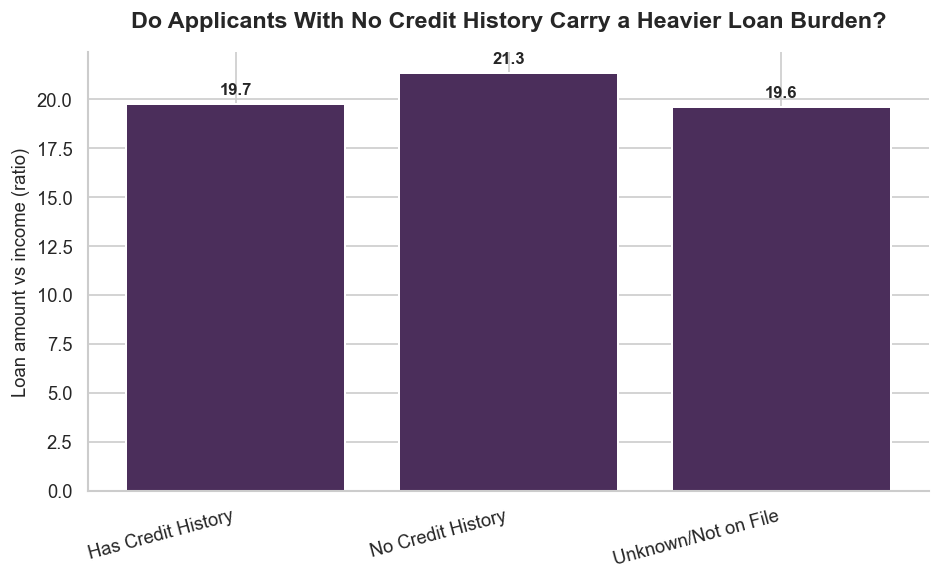

In [74]:
ratio = df.groupby("Credit_History_Status")["LoanIncomeRatio"].mean().round(2)
pretty_bar(ratio, "Do Applicants With No Credit History Carry a Heavier Loan Burden?", "Loan amount vs income (ratio)", color="#4B2E5B")

**What this shows:** Yes. Applicants with no credit history on file have the highest loan-to-income ratio, meaning they're asking for more relative to what they earn.

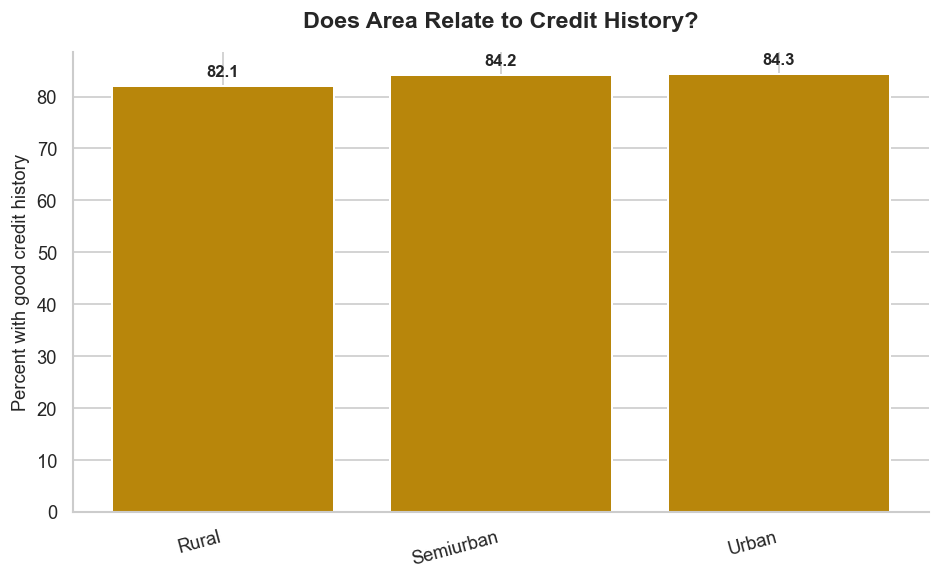

In [75]:
rate_area = (df.groupby("Property_Area")["Credit_History"].mean() * 100).round(1)
pretty_bar(rate_area, "Does Area Relate to Credit History?", "Percent with good credit history", color="#B8860B")

**What this shows:** Not much. Rural, Semiurban, and Urban applicants are all within about 2 percentage points of each other.

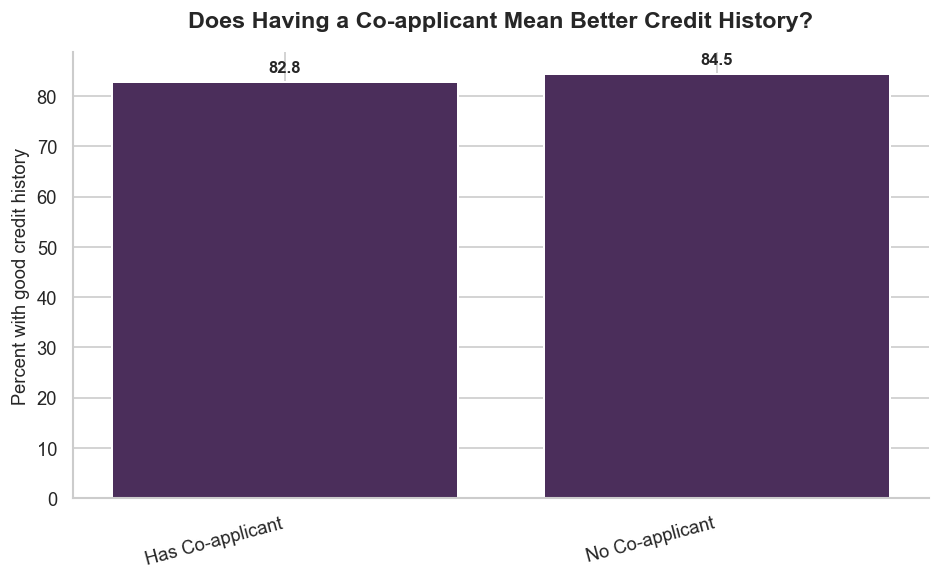

In [76]:
df["Coapplicant_Label"] = df["Has_Coapplicant"].map({0: "No Co-applicant", 1: "Has Co-applicant"})
rate_coapp = (df.groupby("Coapplicant_Label")["Credit_History"].mean() * 100).round(1)
pretty_bar(rate_coapp, "Does Having a Co-applicant Mean Better Credit History?", "Percent with good credit history", color="#4B2E5B")

**What this shows:** No. Credit history rate is about the same, slightly lower with a co-applicant. Having a second earner does not clearly lower risk here.

## Part 6: Relationships Between Variables

Beyond single comparisons, let's look at how multiple numbers move together.

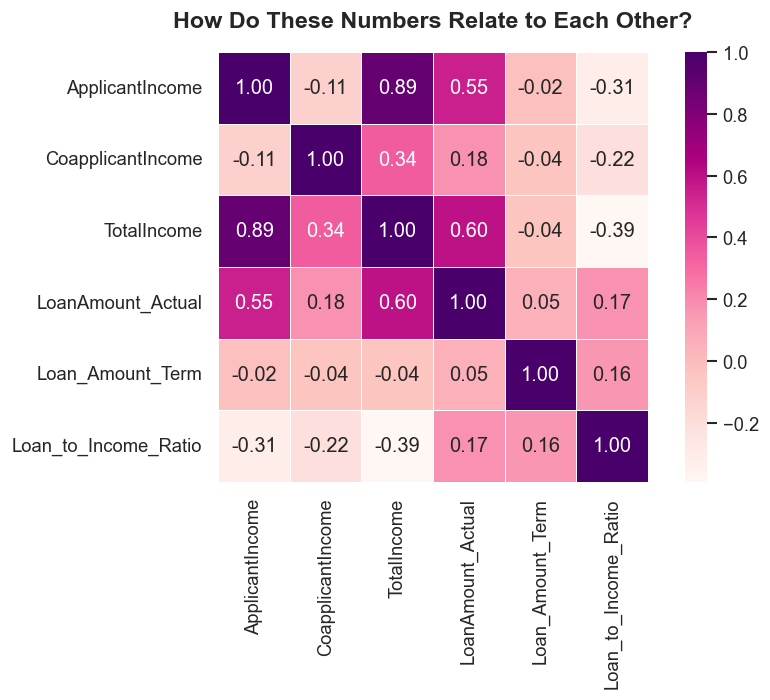

In [77]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome', 'LoanAmount_Actual', 'Loan_Amount_Term', 'Loan_to_Income_Ratio']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdPu", square=True, linewidths=0.5, ax=ax)
ax.set_title("How Do These Numbers Relate to Each Other?", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

**What this shows:** Total income and loan amount have a moderate positive relationship (around 0.60), higher earners do request bigger loans, but the relationship is loose, not tight. Loan term barely relates to anything else.

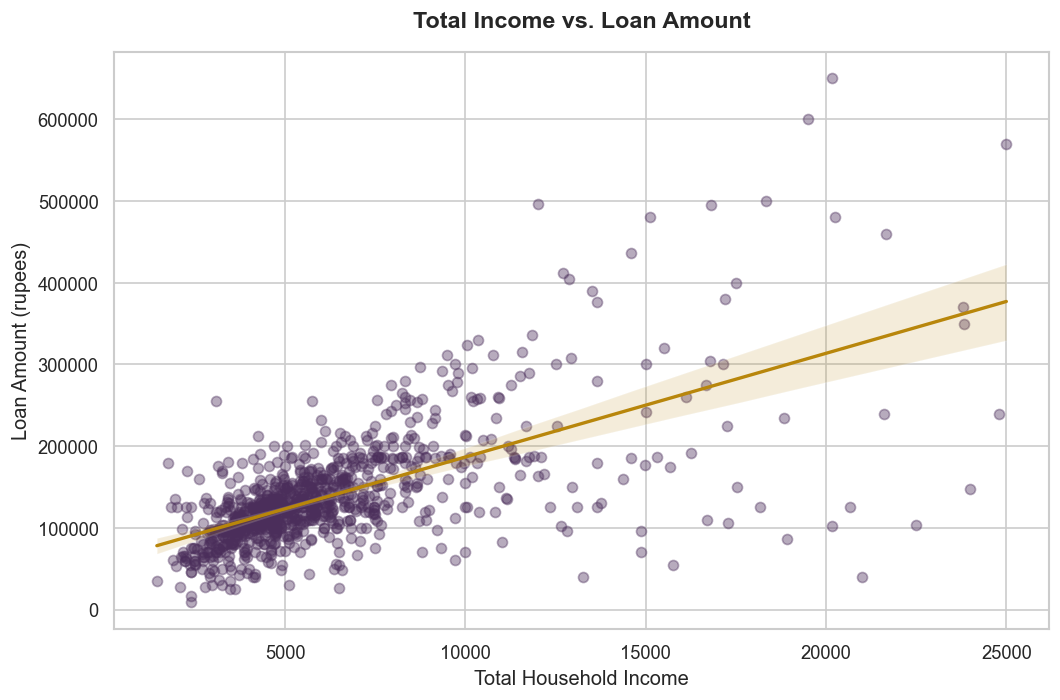

In [78]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(data=df[df['TotalIncome'] < 25000], x="TotalIncome", y="LoanAmount_Actual",
            scatter_kws={"alpha": 0.4, "color": "#4B2E5B"}, line_kws={"color": "#B8860B", "linewidth": 2})
ax.set_title("Total Income vs. Loan Amount", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Total Household Income")
ax.set_ylabel("Loan Amount (rupees)")
plt.tight_layout()
plt.show()

**What this shows:** The gold trend line slopes upward, confirming income and loan size move together, but the scattered dots show plenty of applicants who don't follow that trend, income alone would be a weak way to size a loan.

## Conclusion

After cleaning six data quality problems, and no target column at all. Analyzing the cleaned data revealed that credit history is the strongest and most reliable signal in this dataset, and one of the clearest patterns is that applicants with 3 or more dependents have a meaningfully lower credit history rate than smaller households.

At the same time, several common assumptions did not hold up under real scrutiny: loan size, having a co-applicant, and self-employment status did not correlate with worse credit history the way they're often assumed to. Reporting this honestly, rather than forcing the data to match expectations, is what makes this analysis trustworthy.

Because there is no historical approval outcome in this dataset, these findings cannot predict a bank's actual decision. Instead, they support building a transparent Approval Readiness Score that sorts applicants into High, Medium, and Low bands, letting a lender fast-track the clear majority of applications and focus manual attention only where the data actually suggests it's needed.